In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
trans_from_state_indices = np.load('../Inputs/trans_from_Rfeat.npy')
weight_in = np.load('../Inputs/weights_in_Uniform_microstate_wise.npy')
state_indice_rmsd_exact_prob_synMD = np.load('../Inputs/state_indice_rmsd_exact_prob.npy')

In [3]:
with h5py.File('../Reweights.h5', 'r') as f:
    dset = f['weights_out'] 
    weights_out_raw = np.array(dset)
weights_out_C500 = weights_out_raw
print(np.max(weights_out_C500[-1,:]))

print(np.max(weights_out_C500[0,:]))
print(np.max(weights_out_C500[-1,:]))

0.00020453475
0.00030734894
0.00020453475


In [4]:
# First subplot
Counts_exact_, bin_edges_exact_ = np.histogram(state_indice_rmsd_exact_prob_synMD[:,0],weights=state_indice_rmsd_exact_prob_synMD[:,2], bins=20, density=True)

In [5]:
Counts_exact_weight_in, bin_edges_exact_weight_in = np.histogram(trans_from_state_indices[:,0],weights=weight_in[:], bins=bin_edges_exact_, density=True)

In [6]:
bin_mid_exact_ = (bin_edges_exact_[:-1]+bin_edges_exact_[1:])/2
bin_width = bin_edges_exact_[1]-bin_edges_exact_[0]

In [7]:
# First subplot
Counts_est_iter_wise_C500 = np.full((len(Counts_exact_),len(weights_out_C500)),np.nan)

for i in range(len(weights_out_C500)):
    Counts_est_tmp, bin_edges_est = np.histogram(trans_from_state_indices[:,0],weights=weights_out_C500[i,:], bins=bin_edges_exact_, density=True)
    Counts_est_iter_wise_C500[:,i] = Counts_est_tmp

(1000, 4)


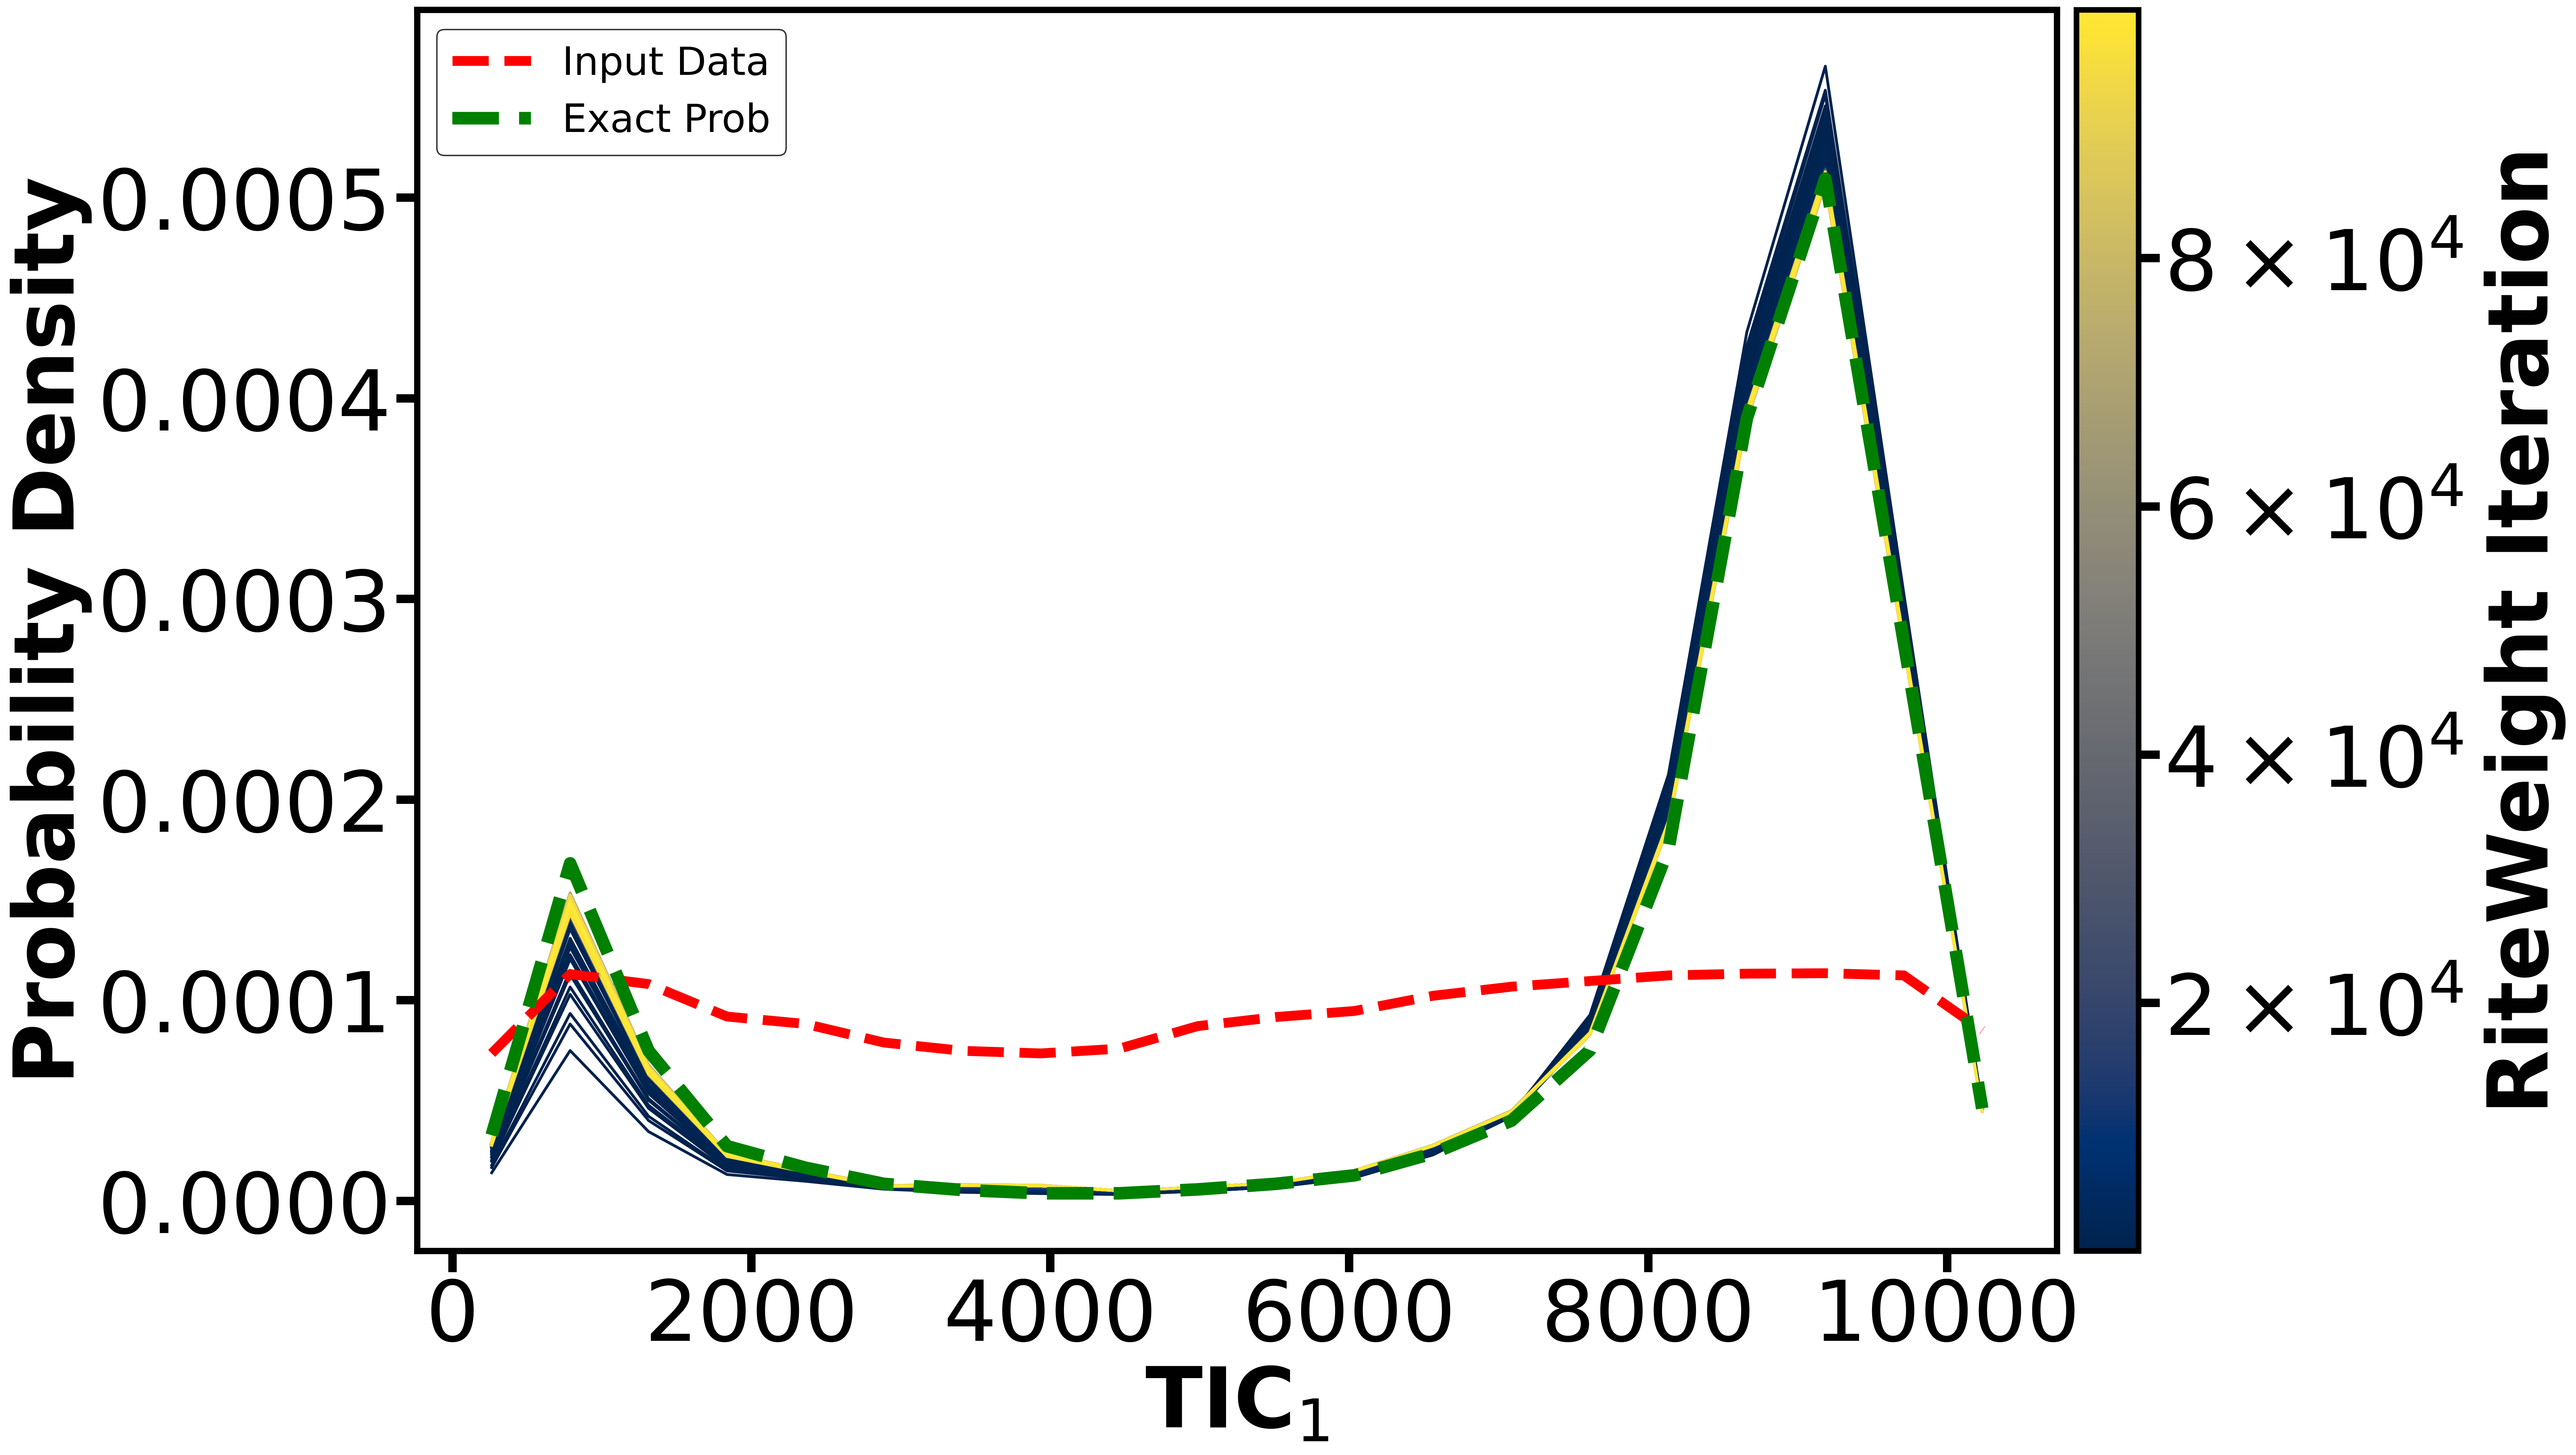

In [11]:
# Create a colormap
max_out_weight = len(weights_out_C500)
weights_freq = 100
# Create a colormap with 50 distinct colors
iter_max_shown = max_out_weight
colors = cm.cividis(np.linspace(0, 1, iter_max_shown))
print(colors.shape)


# Create figure with poster size
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(25, 16), dpi=300)

for i in range(0,iter_max_shown):
    #time.sleep(1) 
    color = colors[i]
    # Only plot the red and green lines once, outside the loop
    # Plot each iteration line with a different color
    ax1.plot(bin_mid_exact_, Counts_est_iter_wise_C500[:, i], color=color, linewidth=2.0)
ax1.plot(bin_mid_exact_, Counts_exact_weight_in[:], color='red', linestyle='--', linewidth=7.0, label='Input Data')
ax1.plot(bin_mid_exact_, Counts_exact_[:], color='green', linestyle='--', linewidth=9.0, label='Exact Prob')
    

# Create the ScalarMappable object for the color bar
sm = plt.cm.ScalarMappable(cmap=cm.cividis, norm=plt.Normalize(vmin=0, vmax=iter_max_shown*weights_freq))  # Adjust vmax based on your data range
sm.set_array([])  # Set an empty array since the color mapping is based on iteration numbers
cbar = fig.colorbar(sm, ax=[ax1], orientation='vertical', pad=0.01)

# Set custom ticks and labels (k-format)
cbar.set_ticks([20000, 40000, 60000, 80000])
cbar.set_ticklabels(['20k', '40k', '60k', '80k'])

from matplotlib.ticker import FuncFormatter
# Define custom formatter
def sci_tick_format(x, pos):
    return r'${:.0f} \times 10^4$'.format(x / 1e4)

# Set ticks and formatter
cbar.set_ticks([20000, 40000, 60000, 80000])
cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_tick_format))

cbar.ax.tick_params(labelsize=60, width=6.0, length=15)
#for tick in cbar.ax.get_yticklabels():
    #tick.set_weight('bold')
cbar.set_label("RiteWeight Iteration", fontsize=60, weight='bold', labelpad=15)
#for tick in cbar.ax.get_yticklabels():
    #tick.set_weight('bold')
# Customize colorbar border
cbar.outline.set_linewidth(4.0)
cbar.outline.set_edgecolor('black')


# Add labels with bold text ax1.set_xlabel(r"TIC$_1$", fontsize=60, weight='bold')
ax1.set_xlabel(r"TIC$_1$" , fontsize=60, weight='bold')
ax1.set_ylabel("Probability Density", fontsize=60, weight='bold')

ax1.tick_params(axis='both', which='major', labelsize=60, width=6.0, length=15)

# Make only the bottom x-axis and left y-axis visible and thick
ax1.spines['top'].set_linewidth(4.5)   # Hide top axis
ax1.spines['right'].set_linewidth(4.5)  # Hide right axis
ax1.spines['bottom'].set_linewidth(4.5)  # Make bottom x-axis thicker
ax1.spines['left'].set_linewidth(4.5)    # Make left y-axis thicker
ax1.legend(loc='best', fontsize=28, frameon=True, edgecolor='black')
fig.savefig('GitHub_Sep20VersionCheck.png', format='png', bbox_inches='tight')